# BÀI TẬP: EDA HOÀN CHỈNH — TITANIC
## Data Profiling → Descriptive Statistics → Define the Question
**Nguồn:** kaggle.com/c/titanic (891 dòng)

```
PHẦN A — DATA PROFILING       : dữ liệu sạch chưa, có gì
PHẦN B — DESCRIPTIVE STATS    : từng biến trông như thế nào
PHẦN C — DEFINE THE QUESTION  : đặt câu hỏi kinh doanh, trả lời bằng code, rút insight
```

## Setup

In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [3]:
# TODO
df.shape #Data size

(891, 15)

In [4]:
df.size

13365

In [5]:
df.columns.tolist() 

['survived',
 'pclass',
 'sex',
 'age',
 'sibsp',
 'parch',
 'fare',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone']

In [6]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [7]:
df.dtypes

survived         int64
pclass           int64
sex             object
age            float64
sibsp            int64
parch            int64
fare           float64
embarked        object
class           object
who             object
adult_male        bool
deck            object
embark_town     object
alive           object
alone             bool
dtype: object

## A.2. Missing values & Duplicate data

In [8]:
# TODO
df.isnull().sum() 

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(107)

In [10]:
# TODO
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
886     True
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

## A.3. Invalid values

In [11]:
# TODO
(df['age']>25).sum()

np.int64(413)

## A.4. Create a new column
Tạo cột `family_size` = sibsp + parch + 1.

In [12]:
# TODO
df['family_size']=df['sibsp'] + df['parch'] + 1
df



,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,1
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,1
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,4
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,1


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [13]:
# TODO
df[['age','fare','family_size']].mean()


age            29.699118
fare           32.204208
family_size     1.904602
dtype: float64

## Group 2 — Dispersion

In [14]:
# TODO
df.describe()

,survived,pclass,age,sibsp,parch,fare,family_size
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,1.904602
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,1.613459
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,1.000000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,2.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,11.000000


In [15]:
df[['age','fare','family_size']].std()
df[['age','fare','family_size']].describe()


,age,fare,family_size
count,714.000000,891.000000,891.000000
mean,29.699118,32.204208,1.904602
std,14.526497,49.693429,1.613459
min,0.420000,0.000000,1.000000
25%,20.125000,7.910400,1.000000
50%,28.000000,14.454200,1.000000
75%,38.000000,31.000000,2.000000
max,80.000000,512.329200,11.000000


## Group 3 — Location and Shape

<Axes: xlabel='age', ylabel='Count'>

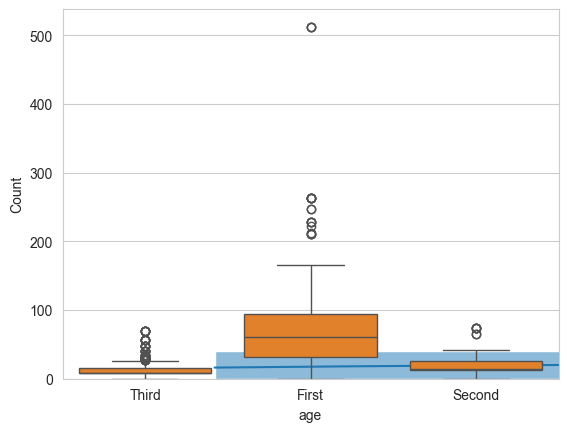

In [16]:

# TODO
sns.histplot(df['age'], kde=True)
sns.boxplot(x='class', y='fare', data=df)


---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Hạng vé nào có tỷ lệ sống sót cao nhất, chênh lệch bao nhiêu so với hạng thấp nhất?

In [17]:
# TODO
survival_by_class = df.groupby('class')['survived'].mean()

diff_class = survival_by_class.max() - survival_by_class.min()

print(f"=> Hạng vé có tỷ lệ sống sót cao nhất là {survival_by_class.idxmax()} ({survival_by_class.max()*100:.2f}%).")
print(f"=> Chênh lệch so với hạng thấp nhất ({survival_by_class.idxmin()} - {survival_by_class.min()*100:.2f}%) là {diff_class*100:.2f}%.")


=> Hạng vé có tỷ lệ sống sót cao nhất là First (62.96%).
=> Chênh lệch so với hạng thấp nhất (Third - 24.24%) là 38.73%.


## Câu hỏi 2: Giới tính hay hạng vé ảnh hưởng đến sống sót mạnh hơn?

In [24]:
# TODO
survival_by_sex = df.groupby('sex')['survived'].mean()
diff_sex = survival_by_sex.max() - survival_by_sex.min()

print(f"=> Chênh lệch tỷ lệ sống sót theo Giới tính: {diff_sex*100:.2f}% (Nữ: {survival_by_sex['female']*100:.2f}% vs Nam: {survival_by_sex['male']*100:.2f}%).")

print(f"=> Kết luận: {'Giới tính' if diff_sex > diff_class else 'Hạng vé'} ảnh hưởng mạnh hơn đến khả năng sống sót.")

=> Chênh lệch tỷ lệ sống sót theo Giới tính: 55.31% (Nữ: 74.20% vs Nam: 18.89%).
=> Kết luận: Giới tính ảnh hưởng mạnh hơn đến khả năng sống sót.


## Câu hỏi 3: Vé đắt hơn có thực sự sống sót cao hơn không?

=> Có, hành khách mua vé giá cao hơn (thường thuộc First Class) có tỷ lệ sống sót cao hơn rõ rệt.


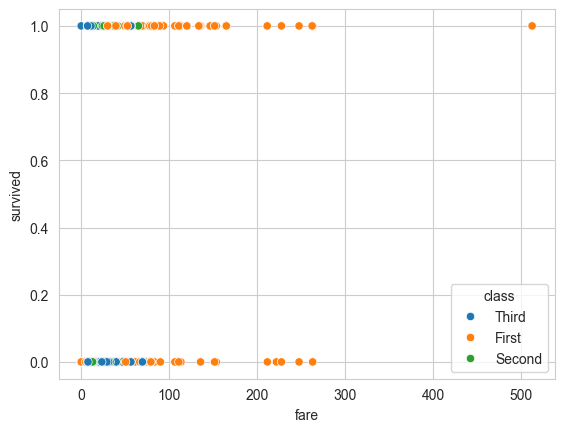

In [28]:
# TODO
sns.scatterplot(x='fare', y='survived', hue='class', data=df)
print("=> Có, hành khách mua vé giá cao hơn (thường thuộc First Class) có tỷ lệ sống sót cao hơn rõ rệt.")

## Câu hỏi 4: Gia đình đông người có ảnh hưởng đến khả năng sống sót không?

In [29]:
# TODO
survival_by_family = df.groupby('family_size')['survived'].mean()
print(f"=> Nhóm gia đình nhỏ (2-4 người) có tỷ lệ sống sót : {survival_by_family.loc[2:4].mean()*100:.2f}%.")
print(f"=> Đi đơn lẻ (1 người: {survival_by_family[1]*100:.2f}%) hoặc gia đình quá đông (>=5 người: {survival_by_family.loc[5:].mean()*100:.2f}%) .")

=> Nhóm gia đình nhỏ (2-4 người) có tỷ lệ sống sót : 61.85%.
=> Đi đơn lẻ (1 người: 30.35%) hoặc gia đình quá đông (>=5 người: 13.39%) .


## Câu hỏi 5: Cảng lên tàu (embark_town) nào có tỷ lệ sống sót cao nhất?

In [31]:
# TODO
survival_by_embark = df.groupby('embark_town')['survived'].mean()
print(f"=> Cảng lên tàu có tỷ lệ sống sót cao nhất là {survival_by_embark.idxmax()} ({survival_by_embark.max()*100:.2f}%).")


=> Cảng lên tàu có tỷ lệ sống sót cao nhất là Cherbourg (55.36%).


## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể về dữ liệu Titanic.

nữ giới và hành khách Hạng 1 có cơ hội sống sót vượt trội nhờ được ưu tiên lên xuồng và vị trí cabin thuận lợi, trong khi nam giới Hạng 3 chịu tỷ lệ tử vong cao nhất

những người đi theo nhóm gia đình nhỏ từ 2–4 người có tỷ lệ thoát nạn tốt hơn hẳn so với người đi đơn lẻ hoặc nhóm quá đông.